# vsEOF.ipynb

- This notebook reproduces the following EOF-related figures in Guo et al. (2026).
    - Supplementary figures S2–S4
- **Additional data reminder**:
    - ERA5 IVT (2001–2019): calculate with `/src/main/data_processing/cal_ERA5_IVT.py`, with U, V, Q  downloaded from (https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=download), to be downloaded from Zenodo (doi:10.5281/zenodo.17199183)
- Execution order of cell sections for reproducing figures: 
    1. `Import`
    2. `Utilities`
    3. Each `Figure: ...`

# Import

In [1]:
import numpy as np
import netCDF4 as nc
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn.colors.xkcd_rgb as c
import cmaps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import tensorflow as tf
from tensorflow.keras import layers, Input, backend, Model, losses, optimizers, models

In [2]:
# --- self define modules --- #
import importlib
import sys
sys.path.append('../../src/vae/')
import ML_model_data
importlib.reload(ML_model_data)

<module 'ML_model_data' from '/home/ch995334/Multiscale-MoistDyn-Control/notebooks/vae/../../src/vae/ML_model_data.py'>

# Utilities

In [4]:
latent_dim       =2
encoder, decoder = ML_model_data.Load_ML()

## !!

In [5]:
# Original IVT
era5_IVT_all = xr.open_dataset('../../data/processed/IVT_1000_700_2001_2019.nc') # download from zenodo
# Normalized IVT (training, validation, and testing)
era5_normIVT_ssn_train= ML_model_data.Load_Dataset()['x_train']
era5_normIVT_ssn_val = ML_model_data.Load_Dataset()['x_val']
era5_normIVT_ssn_test = ML_model_data.Load_Dataset()['x_test']

## VAE-related data

In [6]:
# Latent vectors
era5_lvIVT_ssn_train= ML_model_data.Load_latent_vectors('ERA5(train)')
era5_lvIVT_ssn_test   = ML_model_data.Load_latent_vectors('ERA5(test)')
# Reconstruction
era5_reconIVT_ssn_train= ML_model_data.Load_reconstruction(era5_lvIVT_ssn_train)
era5_reconIVT_ssn_test= ML_model_data.Load_reconstruction(era5_lvIVT_ssn_test)

2026-01-03 17:08:37.318388: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2026-01-03 17:08:37.330815: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2100000000 Hz


## Plotting aids

In [7]:
def Plot_2D_map(axe, lon_, lat_,
                xlim_, ylim_, xloc_, yloc_, arr_,
                bound_, cmap_, norm_=None, alpha_=None, extend_='neither', bottom_label_=False, left_label_=False):
    """
    2D map with geographical settings
    """
    axe.set_extent([xlim_[0], xlim_[-1], ylim_[0], ylim_[-1]], crs=ccrs.PlateCarree())
    axe.add_feature(cfeature.LAND,color='grey',alpha=0.1)
    axe.coastlines(resolution='50m', color='black', linewidth=1)
    if bottom_label_:
        gx = axe.gridlines(xlocs=xloc_, crs=ccrs.PlateCarree(), zorder=1)
        gx.bottom_labels = True
    if left_label_:
        gy = axe.gridlines(ylocs=yloc_, crs=ccrs.PlateCarree(), zorder=1)
        gy.left_labels = True
        
    im = axe.contourf(lon_,lat_,arr_,
                      transform=ccrs.PlateCarree(),
                      levels=bound_, extend=extend_, cmap=cmap_, alpha=alpha_, norm=norm_)
    return im

In [8]:
def Colorinfo(fig, axe, type_:str, pos_:list,  
              fs_:int, title_=None, title_fs_=None,
              var_=None, cmap_=None, alpha_=1, extend_='neither',
              ticks_=None, labels_=None):
    """
    2 options: legend/colorbar
    """
    if type_=='legend':
        legend = axe.legend(bbox_to_anchor=pos_,
                             title=title_, 
                             fontsize=fs_, title_fontsize=fs_)
        for lh in legend.legendHandles: 
            lh.set_alpha(1)
        return legend
    elif type_=='colorbar':
        cax     = fig.add_axes(pos_)
        cbar    = fig.colorbar(var_, extend=extend_, cax=cax)
        cbar.solids.set(alpha=alpha_)  # Default: set cbar to full color (w/out tranparency)
        cbar.set_ticks(ticks=ticks_, labels=labels_)
        cbar.ax.tick_params(labelsize=fs_)
        cbar.set_label(title_, fontsize=title_fs_)
        return cbar

In [9]:
def Fig_title(axe, 
              right_title_='', mid_title_='', left_title_='', title_fs_=None,):
    axe.set_title(right_title_, loc='right', fontsize=title_fs_)
    axe.set_title(mid_title_, fontsize=title_fs_)
    axe.set_title(left_title_, loc='left', fontsize=title_fs_)

# EOF (with norm. IVT fields)
The norm. IVT fields are identical to the inputs of VAE.

In [10]:
era5_train_reshape = era5_normIVT_ssn_train.reshape(era5_normIVT_ssn_train.shape[0], 
                                                    era5_normIVT_ssn_train.shape[1]*era5_normIVT_ssn_train.shape[2])
era5_test_reshape  = era5_normIVT_ssn_test.reshape(era5_normIVT_ssn_test.shape[0], 
                                                   era5_normIVT_ssn_test.shape[1]*era5_normIVT_ssn_test.shape[2])
era5_all_reshape   = np.concatenate((era5_normIVT_ssn_train, era5_normIVT_ssn_val, era5_normIVT_ssn_test), axis=0).reshape((era5_normIVT_ssn_train.shape[0]+era5_normIVT_ssn_val.shape[0]+era5_normIVT_ssn_test.shape[0]), era5_normIVT_ssn_test.shape[1]*era5_normIVT_ssn_test.shape[2])

In [11]:
# standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(era5_train_reshape)
era5_train_std = sc.transform(era5_train_reshape)
era5_test_std  = sc.transform(era5_test_reshape)
era5_all_std   = sc.transform(era5_all_reshape)

In [12]:
# fit with training set, transform testing set
from sklearn.decomposition import PCA
n_components    = 2
pca             = PCA(n_components=n_components)
era5_train_fit  = pca.fit(era5_train_std)
era5_test_trans = era5_train_fit.transform(era5_test_std)
era5_all_trans  = era5_train_fit.transform(era5_all_std)

In [13]:
# Reconstruction with 2 EOF modes (only testing set)
pca_recon_std = pca.inverse_transform(era5_test_trans)
pca_recon     = sc.inverse_transform(pca_recon_std)
pca_recon     = pca_recon.reshape(era5_normIVT_ssn_test.shape[0], 
                                  era5_normIVT_ssn_test.shape[1], era5_normIVT_ssn_test.shape[2])

In [14]:
# Reconstruction with 2 EOF modes (entire set)
pca_recon_all_std = pca.inverse_transform(era5_all_trans)
pca_recon_all     = sc.inverse_transform(pca_recon_all_std)
pca_recon_all     = pca_recon_all.reshape((era5_normIVT_ssn_train.shape[0]+era5_normIVT_ssn_val.shape[0]+era5_normIVT_ssn_test.shape[0]), 
                                          era5_normIVT_ssn_test.shape[1], era5_normIVT_ssn_test.shape[2])

## Metrics

### Pattern correlation

In [15]:
def weighted_patt_corr(org_array:np.ndarray, pred_array:np.ndarray, lat_info:np.ndarray)->np.ndarray:
    if len(org_array.shape) > 3: org_array = org_array[..., 0]      # check org_array's dimension
    if len(pred_array.shape) > 3: pred_array = pred_array[..., 0]   # check pred_array's dimension
    weighting    = np.cos(lat_info*np.pi/180)                       # geographical weighting
    weighting_2d = np.repeat(weighting[:, np.newaxis], axis=-1, repeats=org_array.shape[2])
    patt_corr    = np.zeros(org_array.shape[0])
    for dd in range(org_array.shape[0]):
        wmean_org, wmean_pred = np.mean(org_array[dd, :]*weighting_2d), np.mean(pred_array[dd, :]*weighting_2d)
        nominator = weighting_2d*(org_array[dd, :]-wmean_org)*(pred_array[dd, :]-wmean_pred)
        wcovar    = nominator.sum()/weighting_2d.sum()
        patt_corr[dd] = wcovar/(np.std(org_array[dd, :])*np.std(pred_array[dd, :]))
    return patt_corr

In [16]:
era5_patcor_pca = weighted_patt_corr(era5_normIVT_ssn_test, pca_recon, era5_IVT_all.latitude.data[::5])
era5_patcor_vae = weighted_patt_corr(era5_normIVT_ssn_test, era5_reconIVT_ssn_test, era5_IVT_all.latitude.data[::5])
era5_patcor_vae_train = weighted_patt_corr(era5_normIVT_ssn_train, era5_reconIVT_ssn_train, era5_IVT_all.latitude.data[::5])

### RMSE

In [17]:
era5_rmse_pca = np.sqrt(np.mean((era5_normIVT_ssn_test[..., 0]-pca_recon)**2, axis=(1, 2)))
era5_rmse_vae = np.sqrt(np.mean((era5_normIVT_ssn_test[..., 0]-era5_reconIVT_ssn_test[..., 0])**2, axis=(1, 2)))
era5_rmse_vae_train = np.sqrt(np.mean((era5_normIVT_ssn_train[..., 0]-era5_reconIVT_ssn_train[..., 0])**2, axis=(1, 2)))

### Figure

In [18]:
def Plot_metrics_box_onlyERA5(season:str):
    ssn_color = {'sum':c['crimson'], 'win':c['denim']}
    boxprops_eof = dict(linestyle=':', linewidth=4, color=ssn_color[season])
    boxprops_vae = dict(linestyle='-', linewidth=4, color=ssn_color[season])
    medianprops  = dict(linestyle='-', linewidth=4, color='k')
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(8, 5), gridspec_kw={'wspace':0.25})
    # Pattern Correlation & Explained variance
    ax[0].grid(':', linewidth=0.5, axis='y')
    CE = ax[0].boxplot([era5_patcor_pca], 
                  positions=np.array([0]), labels=['Test'],
                  showfliers=False, boxprops=boxprops_eof, widths=.3, medianprops=medianprops)
    CV = ax[0].boxplot([era5_patcor_vae, era5_patcor_vae_train], 
                  positions=np.array([1, 2]), labels=['Test', 'Train'], 
                  showfliers=False, boxprops=boxprops_vae, widths=.3, medianprops=medianprops)
    CM = ax[0].plot(0, np.mean(era5_patcor_pca**2), 'k*', markersize=15)
    ax[0].plot(1, np.mean(era5_patcor_vae**2), 'k*', markersize=15)
    ax[0].plot(2, np.mean(era5_patcor_vae_train**2), 'k*', markersize=15)

    ax[0].set_xlim([-1, 3])
    ax[0].set_xticklabels(['Test', 'Test', 'Train'], fontsize=14)
    ax[0].set_ylim([0, 1])
    ax[0].set_yticks(np.arange(0, 1.1, 0.1))
    ax[0].set_yticklabels([f'{i:3.1f}' for i in np.arange(0, 1.1, 0.1)], fontsize=12)
    ax[0].legend([CE['boxes'][0], CV['boxes'][0], CM[0]], 
                 ["EOF", "VAE", "Explained Variance"], fontsize=12)
    ax[0].set_title('Pattern Correlation', fontsize=16)

    ax[1].grid(':', linewidth=0.5, axis='y')
    ax[1].boxplot([era5_rmse_pca], 
                  positions=np.array([0]), labels=['Test'], 
                  showfliers=False, boxprops=boxprops_eof, widths=.3, medianprops=medianprops)
    ax[1].boxplot([era5_rmse_vae, era5_rmse_vae_train], 
                  positions=np.array([1, 2]), labels=['Test', 'Train'], 
                  showfliers=False, boxprops=boxprops_vae, widths=.3, medianprops=medianprops)

    ax[1].set_xlim([-1, 3])
    ax[1].set_xticklabels(['Test', 'Test', 'Train', 'Test', 'Test', 'Train'], fontsize=14)
    ax[1].set_ylim([0., 0.2])
    ax[1].set_yticks(np.arange(0, 0.21, 0.025))
    ax[1].set_yticklabels([f'{i:3.3f}' for i in np.arange(0, 0.21, 0.025)], fontsize=12)
    ax[1].set_title(f'RMSE', fontsize=16)

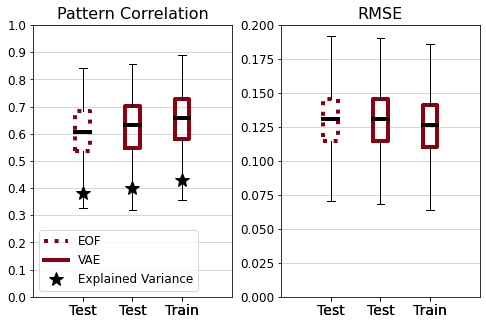

In [19]:
Plot_metrics_box_onlyERA5(season='sum')

## Reconstruction: Case comparison

In [21]:
ssn_date_list = ML_model_data.Xtest_datelist()

In [23]:
def Plot_5cases_compar(season:str):
    proj    = ccrs.PlateCarree()
    fig, ax = plt.subplots(5, 3, figsize=(15, 17), sharex=True, sharey=True,
                           subplot_kw={'projection': proj, "aspect": 1},
                           gridspec_kw = {'wspace':0.1, 'hspace':0.06},
                           )
    for i, case_date in enumerate(case_date_list[season]):
        case_idx = [idx for idx, dd in enumerate(ssn_date_list) if dd==case_date][0]
        im_input= Plot_2D_map(axe=ax[i, 0], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                              xlim_=[65.9, 153.6],
                              ylim_=[-15.1, 30.1], 
                              xloc_=[80, 100, 120, 140], 
                              yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                              arr_ =era5_normIVT_ssn_test[case_idx, ..., 0],
                              bound_=np.arange(0, 0.71, 0.1), 
                              cmap_ = cmaps.MPL_Blues, 
                              extend_='max', bottom_label_=True, left_label_=True)
        im_vae= Plot_2D_map(axe=ax[i, 1], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                            xlim_=[65.9, 153.6],
                            ylim_=[-15.1, 30.1], 
                            xloc_=[80, 100, 120, 140], 
                            yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                            arr_ =era5_reconIVT_ssn_test[case_idx, ..., 0],
                            bound_=np.arange(0, 0.71, 0.1), 
                            cmap_ = cmaps.MPL_Blues, 
                            extend_='max', bottom_label_=True, left_label_=False)
        im_pca= Plot_2D_map(axe=ax[i, 2], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                            xlim_=[65.9, 153.6],
                            ylim_=[-15.1, 30.1], 
                            xloc_=[80, 100, 120, 140], 
                            yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                            arr_ =pca_recon[case_idx, ...],
                            bound_=np.arange(0, 0.71, 0.1), 
                            cmap_ = cmaps.MPL_Blues, 
                            extend_='max', bottom_label_=True, left_label_=False)
        cbar    = Colorinfo(fig=fig, axe=ax[i, 2], type_='colorbar', 
                            pos_ =[ax[i, 2].get_position().x1+0.01, 
                                   ax[i, 2].get_position().y0, 
                                   0.01, 
                                   ax[i, 2].get_position().height], 
                            var_ =im_vae, 
                            cmap_=cmaps.MPL_Blues, 
                            extend_='max',
                            ticks_ =np.arange(0, 0.71, 0.1), fs_  =14,
                            labels_=[f'{i:.1f}' for i in np.arange(0, 0.71, 0.1)])

        Fig_title(axe=ax[i, 0], mid_title_=f'Input', right_title_=f'{case_date}', title_fs_=14)
        Fig_title(axe=ax[i, 1], mid_title_=f'VAE Recon.', title_fs_=14)
        Fig_title(axe=ax[i, 2], mid_title_=f'EOF Recon.', title_fs_=14)

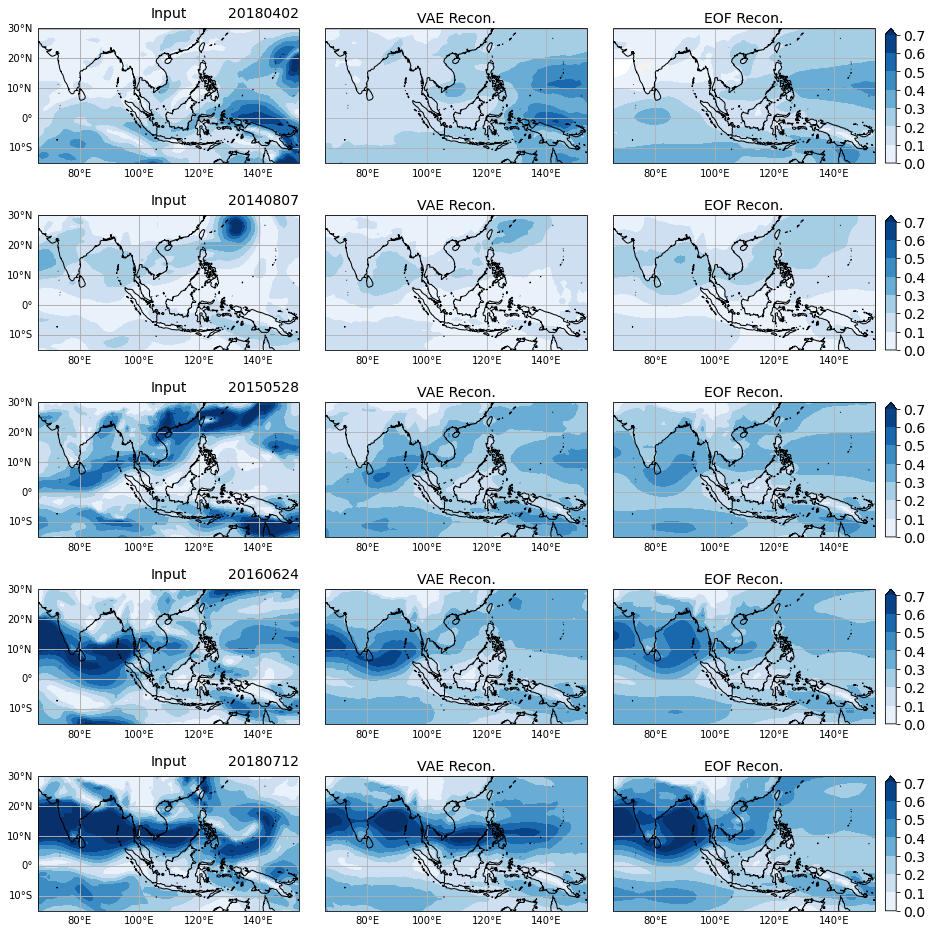

In [25]:
case_date_list = {'sum':['20180402', '20140807', '20150528', '20160624', '20180712']}
Plot_5cases_compar(season='sum')

## EOF phase space clustering 

### Phase space

In [26]:
# pca1, pca2 of testing set
era5_pca1_test = era5_test_trans[:, 0]
era5_pca2_test = era5_test_trans[:, 1]
# pca1, pca2 of the entire set
era5_pca1_all  = era5_all_trans[:, 0]
era5_pca2_all  = era5_all_trans[:, 1]

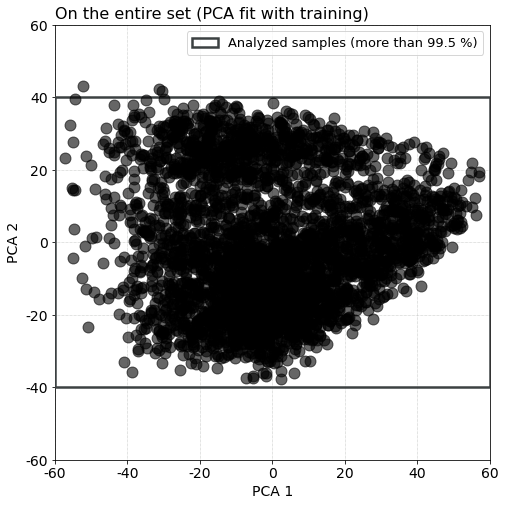

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(linewidth=0.5, linestyle=':', color=c['grey'])
ax.scatter(era5_pca1_all, era5_pca2_all, s=120, color='k', alpha=0.6, zorder=10)  # changed from s=150
rect = patches.Rectangle((-60, -40), 120, 80, fc="none", ec=c['charcoal grey'], linewidth=2.5, zorder=5, label='Analyzed samples (more than 99.5 %)')
ax.add_artist(rect)
ax.set_xlim(-60, 60)
ax.set_xticks(np.arange(-60, 60.1, 20))
ax.set_xticklabels([f'{int(ii)}' for ii in np.arange(-60, 60.1, 20)], fontsize=14)
ax.set_ylim(-60, 60)
ax.set_yticks(np.arange(-60, 60.1, 20))
ax.set_yticklabels([f'{int(ii)}' for ii in np.arange(-60, 60.1, 20)], fontsize=14)
ax.set_xlabel('PCA 1', fontsize=14)
ax.set_ylabel('PCA 2', fontsize=14)
# ax.scatter(-80, -80, s=120, color='k', alpha=0.6, label='testing sample')  # just for legend
ax.legend(fontsize=13)
ax.set_aspect('equal', 'box')
ax.set_title(f'On the entire set (PCA fit with training)', loc='left', fontsize=16)
plt.show()

j=-50.0, 1.7130751609802246
j=-30.0, 0.6111392974853516
j=-10.0, 0.5829929113388062
j=10.0, 0.6692719459533691
j=30.0, 1.1965839862823486
j=50.0, 2.8905460834503174


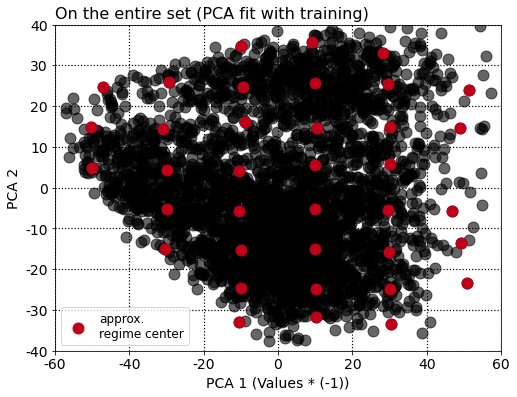

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(linewidth=1.2, linestyle=':', color='k')
ax.scatter(era5_pca1_all*(-1), era5_pca2_all, s=120, color='k', alpha=0.6, zorder=2)  # changed from s=150
# Approximate regime center
for i in np.arange(-35, 35.1, 10):
    for j in np.arange(-50, 50.1, 20):
        tmp     = np.sqrt((era5_pca1_all-j)**2+(era5_pca2_all-i)**2)
        min_idx = np.argmin(tmp)
        if tmp[min_idx]<=3.5:
            ax.scatter(era5_pca1_all[min_idx]*(-1), era5_pca2_all[min_idx], 
                       s=120, color=c['scarlet'], zorder=10)
        if i==25:
            print(f'j={j}, {tmp[min_idx]}')
ax.set_xlim(-60, 60)
ax.set_xticks(np.arange(-60, 60.1, 20))
ax.set_xticklabels([f'{int(ii)}' for ii in np.arange(-60, 60.1, 20)], fontsize=14)
ax.set_ylim(-40, 40)
ax.set_yticks(np.arange(-40, 40.1, 10))
ax.set_yticklabels([f'{int(ii)}' for ii in np.arange(-40, 40.1, 10)], fontsize=14)
ax.set_xlabel('PCA 1 (Values * (-1))', fontsize=14)
ax.set_ylabel('PCA 2', fontsize=14)
# ax.scatter(-80, -80, s=120, color='k', alpha=0.6, label='testing sample')  # just for legend
ax.scatter(-80, -80, s=120, color=c['scarlet'], label='approx.\nregime center')
ax.legend(fontsize=12, loc='lower left')
ax.set_title(f'On the entire set (PCA fit with training)', loc='left', fontsize=16)
plt.show()

### Reconstruction: Latent space

(PCA1=-50.0, PCA2=-35.0): No close enough sample.
(PCA1=30.0, PCA2=-35.0): No close enough sample.
(PCA1=50.0, PCA2=-35.0): No close enough sample.
(PCA1=30.0, PCA2=-25.0): No close enough sample.
(PCA1=50.0, PCA2=-25.0): No close enough sample.
(PCA1=50.0, PCA2=-15.0): No close enough sample.
(PCA1=50.0, PCA2=-5.0): No close enough sample.
(PCA1=-50.0, PCA2=5.0): No close enough sample.
(PCA1=-50.0, PCA2=35.0): No close enough sample.
(PCA1=30.0, PCA2=35.0): No close enough sample.
(PCA1=50.0, PCA2=35.0): No close enough sample.


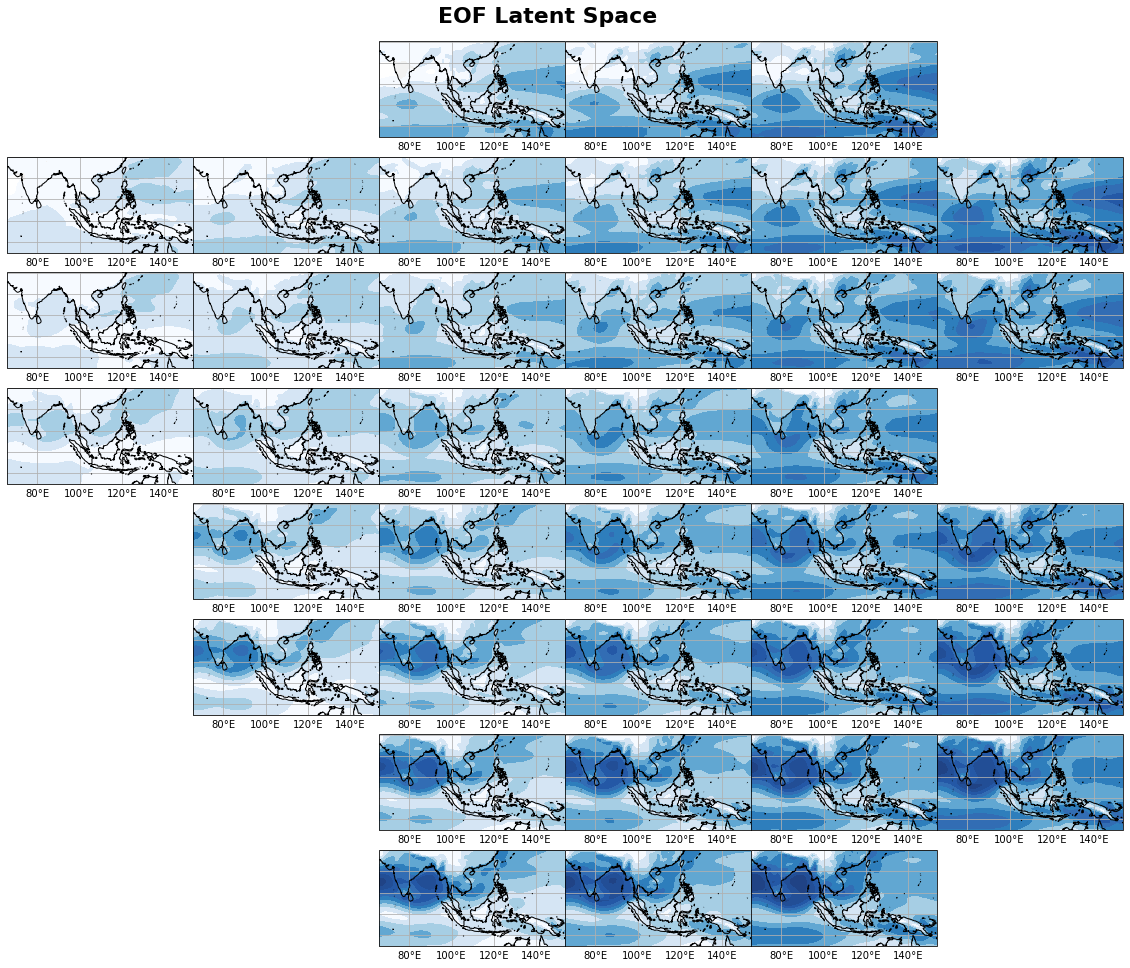

In [30]:
proj    = ccrs.PlateCarree()
fig, ax = plt.subplots(8, 6, figsize=(20, 17),
                       subplot_kw={'projection': proj, "aspect": 1},
                       gridspec_kw = {'wspace':0, 'hspace':0.})
### Two color-scale color map
bounds   = np.arange(0, 0.81,  0.1)
newcolors= np.vstack((cmaps.MPL_Blues(np.linspace(0., 0.7, 5)),
                      cmaps.WhiteBlue(np.linspace(0.75, 0.9, 4)),
                      ))
cmap     = colors.ListedColormap(newcolors, name='TunedBlue')
norm     = colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds), extend='max')
# Plot IVT recon. from the approximate regime centers
for iid, i in enumerate(np.arange(-35, 35.1, 10)):
    for jid, j in enumerate(np.arange(-50, 50.1, 20)):
        tmp     = np.sqrt((era5_pca1_all-j)**2+(era5_pca2_all-i)**2)
        min_idx = np.argmin(tmp)
        if tmp[min_idx]<=3.5:
            im_pca= Plot_2D_map(axe=ax[-(iid+1), -(jid+1)], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                        xlim_=[65.9, 153.6],
                        ylim_=[-15.1, 30.1], 
                        xloc_=[80, 100, 120, 140], 
                        yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                        arr_ =pca_recon_all[min_idx, ...],
                        bound_=bounds, 
                        cmap_ = cmap, 
                        extend_='max', norm_=norm, bottom_label_=True, left_label_=False)
        else:
            fig.delaxes(ax[-(iid+1), -(jid+1)])
            print(f'(PCA1={j:.1f}, PCA2={i:.1f}): No close enough sample.')
fig.suptitle(x=0.5, y=0.9, t='EOF Latent Space', fontsize=22, fontweight='bold')
plt.show()

### Composites

(PCA1=-50.0, PCA2=-35.0): Undefined regimes
(PCA1=30.0, PCA2=-35.0): Undefined regimes
(PCA1=50.0, PCA2=-35.0): Undefined regimes
(PCA1=30.0, PCA2=-25.0): Undefined regimes
(PCA1=50.0, PCA2=-25.0): Undefined regimes
(PCA1=50.0, PCA2=-15.0): Undefined regimes
(PCA1=50.0, PCA2=-5.0): Undefined regimes
(PCA1=-50.0, PCA2=5.0): Undefined regimes
(PCA1=-50.0, PCA2=35.0): Undefined regimes
(PCA1=30.0, PCA2=35.0): Undefined regimes
(PCA1=50.0, PCA2=35.0): Undefined regimes


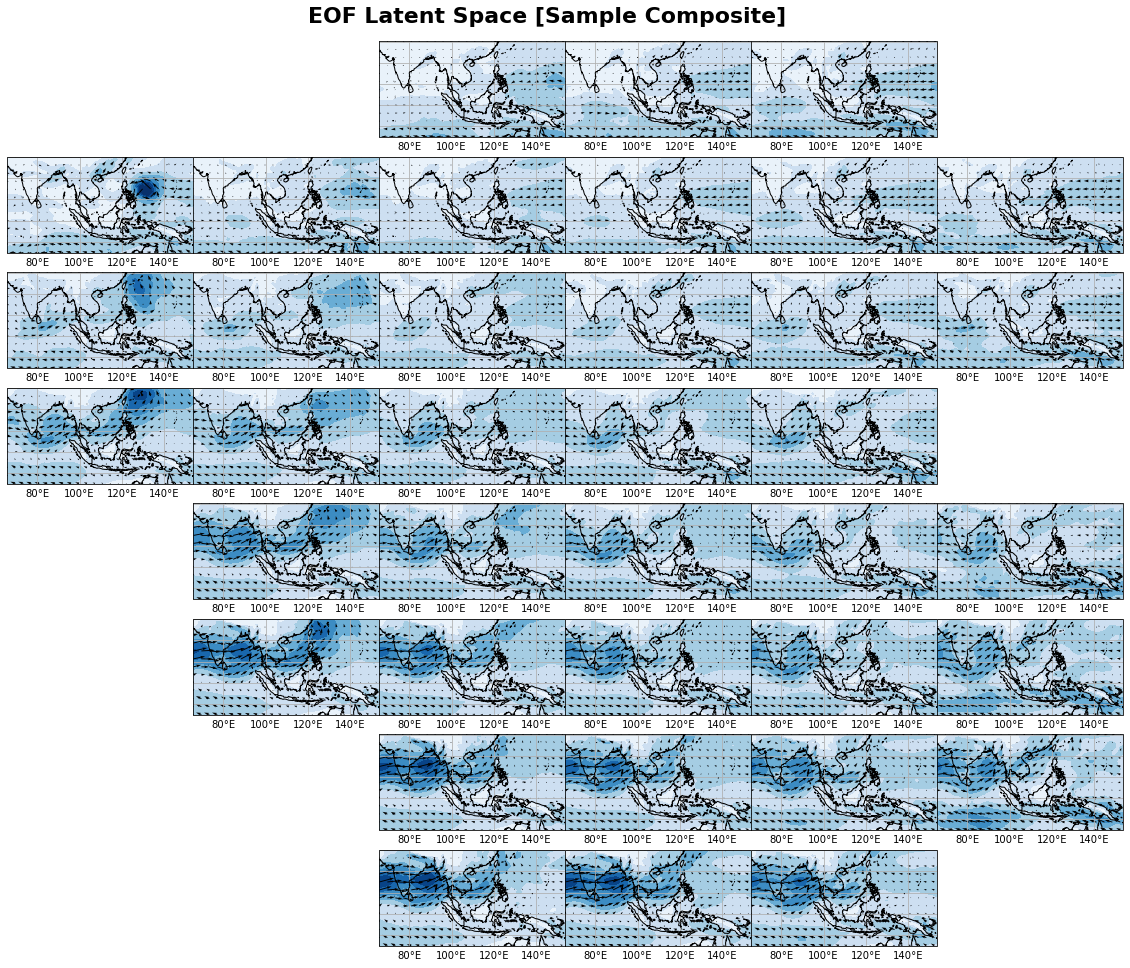

In [31]:
proj    = ccrs.PlateCarree()
fig, ax = plt.subplots(8, 6, figsize=(20, 17),
                       subplot_kw={'projection': proj, "aspect": 1},
                       gridspec_kw = {'wspace':0, 'hspace':0.})
# Plot IVT recon. from the approximate regime centers
for iid, i in enumerate(np.arange(-35, 35.1, 10)):
    for jid, j in enumerate(np.arange(-50, 50.1, 20)):
        tmp     = np.sqrt((era5_pca1_all-j)**2+(era5_pca2_all-i)**2)
        min_idx = np.argmin(tmp)
        # Extract regime samples
        rgm_candj= (era5_pca1_all<j+10)&(era5_pca1_all>=j-5)
        rgm_candi= (era5_pca2_all<i+10)&(era5_pca2_all>=i-5)
        compList = np.arange(era5_pca1_all.shape[0])[rgm_candi&rgm_candj]
        if tmp[min_idx]<=3.5:
            im_pca= Plot_2D_map(axe=ax[-(iid+1), -(jid+1)], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                        xlim_=[65.9, 153.6],
                        ylim_=[-15.1, 30.1], 
                        xloc_=[80, 100, 120, 140], 
                        yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                        arr_ =np.mean((era5_IVT_all.sum_IVT.data)[compList, ::5, ::5], axis=0),
                        bound_=np.arange(0, 700.1, 100), 
                        cmap_ = cmaps.MPL_Blues, 
                        extend_='max', bottom_label_=True, left_label_=False)
            ax[-(iid+1), -(jid+1)].quiver(era5_IVT_all.longitude[::15], era5_IVT_all.latitude[::15], 
                                          np.mean((era5_IVT_all.sum_IVT_u.data)[compList, ::15, ::15], axis=0),
                                          np.mean((era5_IVT_all.sum_IVT_v.data)[compList, ::15, ::15], axis=0), 
                                          scale=8e3, width=5e-3)
        else:
            fig.delaxes(ax[-(iid+1), -(jid+1)])
            print(f'(PCA1={j:.1f}, PCA2={i:.1f}): Undefined regimes')
fig.suptitle(x=0.5, y=0.9, t='EOF Latent Space [Sample Composite]', fontsize=22, fontweight='bold')
plt.show()

### Reconstruction + TC position

(PCA1=-50.0, PCA2=-35.0): Undefined regimes
(PCA1=30.0, PCA2=-35.0): Undefined regimes
(PCA1=50.0, PCA2=-35.0): Undefined regimes
(PCA1=30.0, PCA2=-25.0): Undefined regimes
(PCA1=50.0, PCA2=-25.0): Undefined regimes
(PCA1=50.0, PCA2=-15.0): Undefined regimes
(PCA1=50.0, PCA2=-5.0): Undefined regimes
(PCA1=-50.0, PCA2=5.0): Undefined regimes
(PCA1=-50.0, PCA2=35.0): Undefined regimes
(PCA1=30.0, PCA2=35.0): Undefined regimes
(PCA1=50.0, PCA2=35.0): Undefined regimes


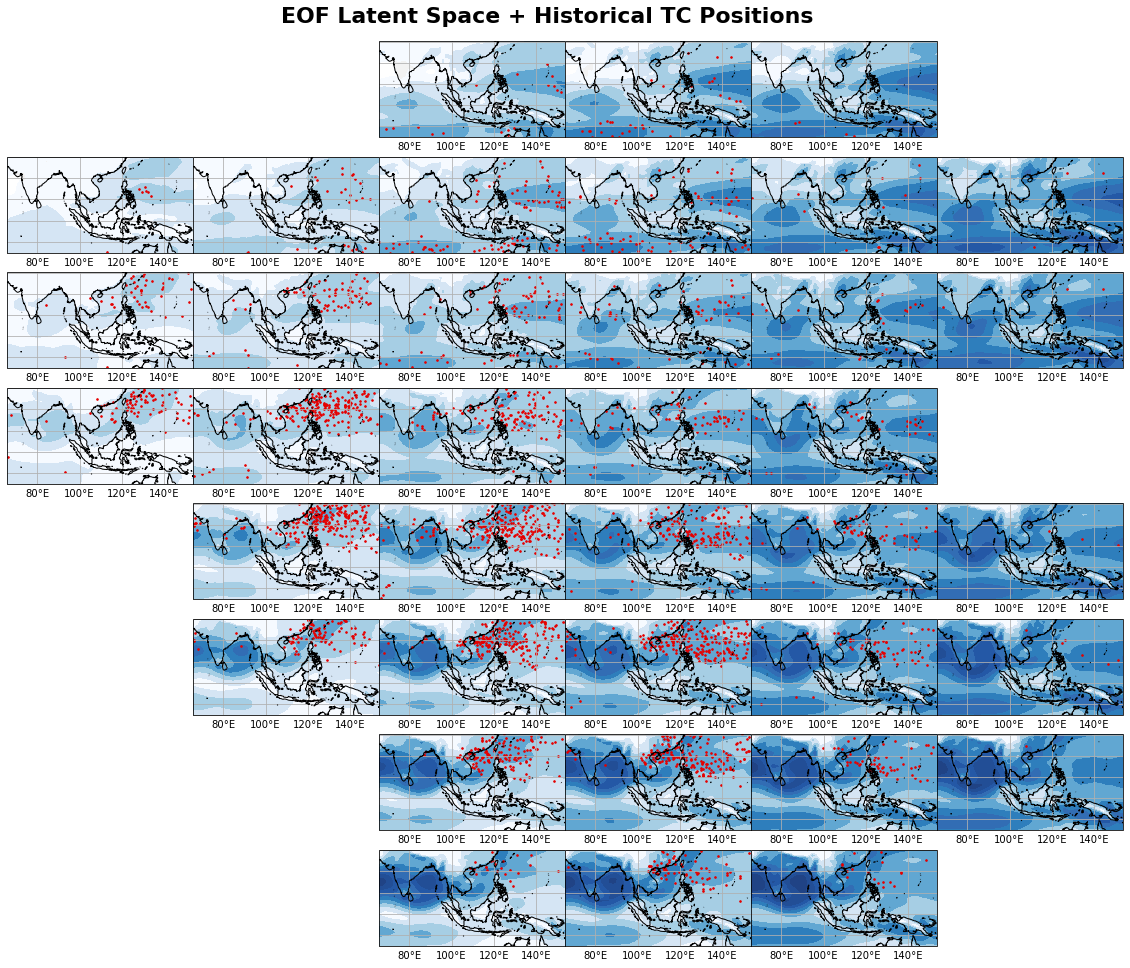

In [34]:
tc_pos_dict = np.load('../../data/processed/sum_storm_dict/sum_storm_dict_TS.npy', allow_pickle=True).item()

proj    = ccrs.PlateCarree()
fig, ax = plt.subplots(8, 6, figsize=(20, 17),
                       subplot_kw={'projection': proj, "aspect": 1},
                       gridspec_kw = {'wspace':0, 'hspace':0.})
# Plot IVT recon. from the approximate regime centers
for iid, i in enumerate(np.arange(-35, 35.1, 10)):
    for jid, j in enumerate(np.arange(-50, 50.1, 20)):
        tmp     = np.sqrt((era5_pca1_all-j)**2+(era5_pca2_all-i)**2)
        min_idx = np.argmin(tmp)
        if tmp[min_idx]<=3.5:
            # Extract regime samples
            rgm_candj= (era5_pca1_all<j+10)&(era5_pca1_all>=j-5)
            rgm_candi= (era5_pca2_all<i+10)&(era5_pca2_all>=i-5)
            compList = np.arange(era5_pca1_all.shape[0])[rgm_candi&rgm_candj]
            # Get TC positions
            tc_lat, tc_lon = [], []
            for dd in np.array(list(tc_pos_dict.keys())[:-1])[compList]:
                tc_lat = tc_lat+tc_pos_dict[dd]['lat']
                tc_lon = tc_lon+tc_pos_dict[dd]['lon']
            im_pca= Plot_2D_map(axe=ax[-(iid+1), -(jid+1)], lon_=era5_IVT_all.longitude[::5], lat_=era5_IVT_all.latitude[::5],
                        xlim_=[65.9, 153.6],
                        ylim_=[-15.1, 30.1], 
                        xloc_=[80, 100, 120, 140], 
                        yloc_=[-20, -10, 0, 10, 20, 30, 35], 
                        arr_ =pca_recon_all[min_idx, ...],
                        bound_=bounds, 
                        cmap_ = cmap, 
                        extend_='max', norm_=norm, bottom_label_=True, left_label_=False)
            # ax[-(iid+1), -(jid+1)].quiver(era5_IVT_all.longitude[::15], era5_IVT_all.latitude[::15], 
            #                               np.mean((era5_IVT_all.sum_IVT_u.data)[compList, ::15, ::15], axis=0),
            #                               np.mean((era5_IVT_all.sum_IVT_v.data)[compList, ::15, ::15], axis=0), 
            #                               scale=8e3, width=5e-3)
            ax[-(iid+1), -(jid+1)].scatter(x=tc_lon, y=tc_lat, s=10, color=c['red'], marker='.')
        else:
            fig.delaxes(ax[-(iid+1), -(jid+1)])
            print(f'(PCA1={j:.1f}, PCA2={i:.1f}): Undefined regimes')
fig.suptitle(x=0.5, y=0.9, t='EOF Latent Space + Historical TC Positions', fontsize=22, fontweight='bold')
plt.show()

### Month transition

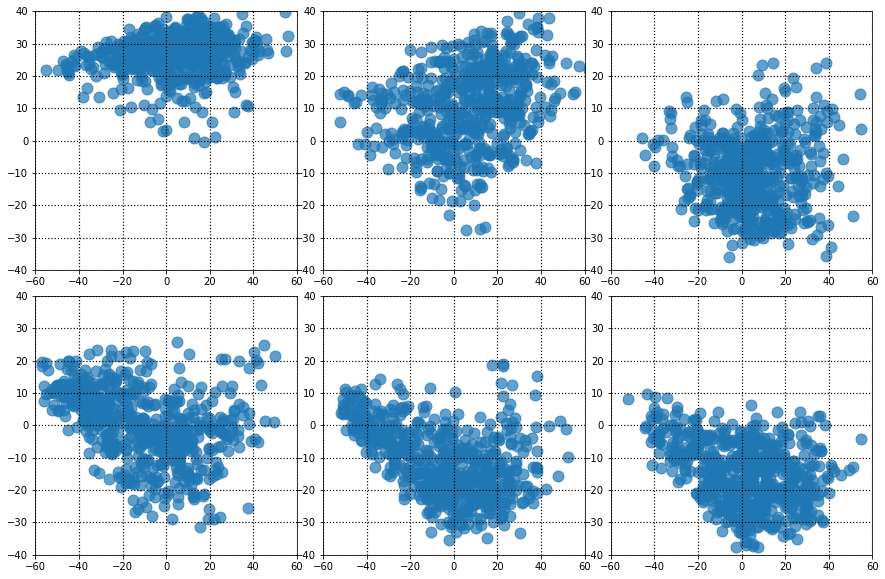

In [35]:
years = range(2001, 2020)
dates_list = [pd.date_range(f'{y}-04-01', f'{y}-09-30', freq='D') for y in years]
time_index = pd.DatetimeIndex(np.concatenate(dates_list))

fig, axes = plt.subplots(2, 3, figsize=(15, 10), gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
plot_idx   = np.array([0, 1, 2, 5, 4, 3])
ax         = axes.flatten()
for i in range(6):
    is_month = (time_index.month == (i+4))
    ax[plot_idx[i]].grid(linestyle=':', linewidth=1.2, color='k')
    ax[plot_idx[i]].scatter(era5_pca1_all[is_month]*(-1), era5_pca2_all[is_month], s=120, alpha=0.7)
    ax[plot_idx[i]].set_xlim(-60, 60)
    ax[plot_idx[i]].set_ylim(-40, 40)
plt.show()